![](https://hleecaster.com/wp-content/uploads/2019/12/logreg01.png)

![](https://hleecaster.com/wp-content/uploads/2019/12/logreg02.png)

### Log-Odds
* 개념

> 선형 회귀에서는 각 속성의 값에다가 계수(coefficient)에 각 곱하고 절편(intercept)을 더해서 예측 값(-∞에서 + ∞)을 구함.

> 로지스틱 회귀에서는 마지막에 예측 값 대신 log-odds를 구함.

![Odds](https://hleecaster.com/wp-content/uploads/2019/12/logreg03.png)

![](https://hleecaster.com/wp-content/uploads/2019/12/logreg04.png)

![](https://hleecaster.com/wp-content/uploads/2019/12/logreg05.png)

 log-odds를 Sigmoid 함수에 넣어서 0부터 1사이의 값으로 변환

![시스모이드함수](https://hleecaster.com/wp-content/uploads/2019/12/logreg08.png)

###Log Loss(로그 손실)
![](https://hleecaster.com/wp-content/uploads/2019/12/logreg10.png)

![](https://hleecaster.com/wp-content/uploads/2019/12/logreg11.png)

![](https://hleecaster.com/wp-content/uploads/2019/12/logreg12.png)


![](https://quantifyinghealth.com/wp-content/uploads/2021/05/Logistic-regression-equation.png)

![](http://people.linguistics.mcgill.ca/~morgan/qmld-book/04-CDA_files/figure-html/logodds-1.png)

In [2]:
import os
os.chdir("/content/drive/MyDrive/kisco/Data")

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
csv_data = pd.read_csv("fish_all.csv")
csv_data.head()

,Species,Weight,Length,Diagonal,Height,Width
0,Bream,242.0,25.4,30.0,11.5200,4.0200
1,Bream,290.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,26.5,31.1,12.3778,4.6961
3,Bream,363.0,29.0,33.5,12.7300,4.4555
4,Bream,430.0,29.0,34.0,12.4440,5.1340


In [6]:
fish_all = csv_data[["Weight", "Length", "Diagonal", "Height", "Width"]]
fish_target = csv_data["Species"]
print(fish_all.shape, fish_target.shape)

(159, 5) (159,)


In [9]:
from sklearn.model_selection import train_test_split
train_data, test_data, train_target, test_target = train_test_split(fish_all, fish_target, stratify=fish_target, random_state=42)
print(train_data.shape, test_data.shape)

(119, 5) (40, 5)


In [10]:
from sklearn.preprocessing import StandardScaler
ss = StandardScaler()
train_scaled = ss.fit_transform(train_data)

In [11]:
test_scaled = ss.transform(test_data)

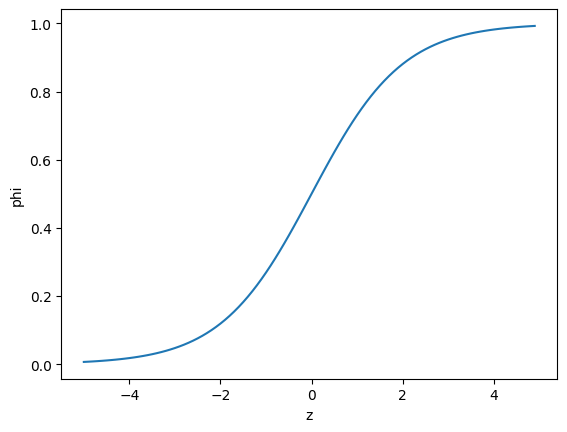

In [12]:
import numpy as np

z = np.arange(-5, 5, 0.1)
phi = 1/(1+np.exp(-z))
plt.plot(z, phi)
plt.xlabel("z")
plt.ylabel("phi")
plt.show() 

### 이항분류

In [13]:
br_sm_indexes = (train_target == "Bream") | (train_target == "Smelt")
train_scaled2 = train_scaled[br_sm_indexes]
train_target2 = train_target[br_sm_indexes]
print(train_scaled2.shape)

(36, 5)


In [16]:
br_sm_indexes2 = (test_target == "Bream") | (test_target == "Smelt")
test_scaled2 = test_scaled[br_sm_indexes2]
test_target2 = test_target[br_sm_indexes2]
print(test_scaled2.shape)

(13, 5)


In [17]:
from sklearn.linear_model import LogisticRegression

LR_model = LogisticRegression()
LR_model.fit(train_scaled2, train_target2)
print("훈련데이터의 정확도 : ", LR_model.score(train_scaled2, train_target2))
print("검증데이터의 정확도 : ", LR_model.score(test_scaled2, test_target2))

훈련데이터의 정확도 :  1.0
검증데이터의 정확도 :  1.0


In [18]:
print(LR_model.predict(train_scaled2[:5]))

['Bream' 'Bream' 'Bream' 'Bream' 'Bream']


In [27]:
print(test_target2[:5])

7     Bream
20    Bream
22    Bream
28    Bream
18    Bream
Name: Species, dtype: object


In [28]:
print(LR_model.predict_proba(test_scaled2[:5]))

[[0.97455817 0.02544183]
 [0.99532877 0.00467123]
 [0.99560927 0.00439073]
 [0.99870256 0.00129744]
 [0.99473941 0.00526059]]


In [ ]:
[0.02544183 0.00467123 0.00439073 0.00129744 0.00526059]

In [29]:
print(LR_model.coef_, LR_model.intercept_)

[[-0.4235112  -0.61604834 -0.70216369 -0.97498265 -0.7403996 ]] [-2.46732659]


In [30]:
print(LR_model.classes_)

['Bream' 'Smelt']


In [31]:
z_value = LR_model.decision_function(test_scaled2[:5])
print(z_value)

[-3.64558962 -5.36165021 -5.42385855 -6.64606299 -5.24223815]


In [32]:
from scipy.special import expit
print(expit(z_value))

[0.02544183 0.00467123 0.00439073 0.00129744 0.00526059]


### 다항분류

In [47]:
model = LogisticRegression(C=20, max_iter=1000) #기본값:C=1(값이 클수록 강도가 약함), max_iter=100
model.fit(train_scaled, train_target)
print("훈련데이터의 정확도 : ", model.score(train_scaled, train_target))
print("테스트데이터의 정확도 : ", model.score(test_scaled, test_target))

훈련데이터의 정확도 :  0.9243697478991597
테스트데이터의 정확도 :  0.975


In [38]:
print(model.classes_)
print(model.predict(test_scaled[:5]))

['Bream' 'Parkki' 'Perch' 'Pike' 'Roach' 'Smelt' 'Whitefish']
['Roach' 'Perch' 'Perch' 'Parkki' 'Parkki']


In [39]:
print(test_target[:5])

42     Roach
85     Perch
79     Perch
64    Parkki
63    Parkki
Name: Species, dtype: object


In [40]:
import numpy as np
proba = model.predict_proba(test_scaled[:5])
print(np.round(proba, decimals=3))

[[0.    0.029 0.237 0.003 0.685 0.01  0.035]
 [0.    0.032 0.576 0.001 0.35  0.003 0.039]
 [0.    0.062 0.558 0.001 0.336 0.017 0.026]
 [0.003 0.93  0.001 0.    0.051 0.    0.015]
 [0.001 0.882 0.004 0.    0.094 0.002 0.017]]


In [ ]:
[[0.    0.029 0.237 0.003 0.685 0.01  0.035]
 [0.    0.032 0.576 0.001 0.35  0.003 0.039]
 [0.    0.062 0.558 0.001 0.336 0.017 0.026]
 [0.003 0.93  0.001 0.    0.051 0.    0.015]
 [0.001 0.882 0.004 0.    0.094 0.002 0.017]]

In [41]:
z_value2 = model.decision_function(test_scaled[:5])
print(np.round(z_value2, decimals=3))

[[-4.554  0.399  2.488 -1.744  3.549 -0.708  0.571]
 [-4.457  0.786  3.681 -2.48   3.184 -1.693  0.978]
 [-5.738  1.39   3.589 -2.949  3.083  0.095  0.532]
 [-0.347  5.411 -1.496 -4.693  2.515 -2.658  1.268]
 [-2.161  4.864 -0.594 -4.539  2.622 -1.095  0.904]]


In [42]:
from scipy.special import softmax
proba2 = softmax(z_value2, axis=1)
print(np.round(proba2, decimals=3))

[[0.    0.029 0.237 0.003 0.685 0.01  0.035]
 [0.    0.032 0.576 0.001 0.35  0.003 0.039]
 [0.    0.062 0.558 0.001 0.336 0.017 0.026]
 [0.003 0.93  0.001 0.    0.051 0.    0.015]
 [0.001 0.882 0.004 0.    0.094 0.002 0.017]]
